In [1]:
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

import numpy
import pandas

import matplotlib.pyplot as plot
import seaborn

In [2]:
save_path = 'exoplanets.csv'

In [3]:
table = NasaExoplanetArchive.query_criteria(
    table = 'PS',
    select = 'pl_name, pl_bmasse, pl_rade, pl_orbeccen, pl_orbper, pl_dens, pl_eqt, pl_pubdate, pl_controv_flag, pl_bmasseerr1, pl_bmasseerr2, pl_radeerr1, pl_radeerr2, soltype, pl_refname',
    where = '''soltype='Published Confirmed' AND pl_bmasse IS NOT NULL AND pl_rade IS NOT NULL AND pl_controv_flag = 0'''
)

full_data = table.to_pandas()

full_data['error_score'] = (
    abs(full_data['pl_bmasseerr1'] / full_data['pl_bmasse']) +
    abs(full_data['pl_bmasseerr2'] / full_data['pl_bmasse']) +
    abs(full_data['pl_radeerr1'] / full_data['pl_rade']) +
    abs(full_data['pl_radeerr2'] / full_data['pl_rade'])
) / 4

full_data['pl_pubdate'] = pandas.to_datetime(full_data['pl_pubdate'])

full_data = full_data.dropna().reset_index(drop = True)

full_data

,pl_name,pl_bmasse,pl_rade,pl_orbeccen,pl_orbper,pl_dens,pl_eqt,pl_pubdate,pl_controv_flag,pl_bmasseerr1,pl_bmasseerr2,pl_radeerr1,pl_radeerr2,soltype,pl_refname,error_score
0,K2-232 b,123.000210,11.859122,0.255,11.168459,0.405,1001.00,2018-09-01,0,13.984520,-13.348860,0.257807,-0.246598,Published Confirmed,<a refstr=YU_ET_AL__2018 href=https://ui.adsab...,0.066189
1,GJ 1214 b,8.170000,2.742000,0.063,1.580404,2.200,596.00,2021-11-01,0,0.430000,-0.430000,0.050000,-0.053000,Published Confirmed,<a refstr=CLOUTIER_ET_AL__2021 href=https://ui...,0.035707
2,Qatar-10 b,233.922880,17.295487,0.000,1.645321,0.248,1955.00,2019-06-01,0,28.604700,-28.604700,0.448360,-0.448360,Published Confirmed,<a refstr=ALSUBAI_ET_AL__2019 href=https://ui....,0.074103
3,WASP-60 b,163.358000,9.640000,0.000,4.305001,1.100,1320.00,2013-01-01,0,10.806000,-10.806000,1.350000,-1.350000,Published Confirmed,<a refstr=HEBRARD_ET_AL__2013 href=https://ui....,0.103095
4,HAT-P-29 b,247.261000,12.408000,0.095,5.723186,0.710,1260.00,2011-06-01,0,24.154000,-12.713000,1.524000,-0.919000,Published Confirmed,<a refstr=BUCHHAVE_ET_AL__2011 href=https://ui...,0.086498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103,pi Men c,4.520000,2.060000,0.000,6.268340,2.820,1147.00,2018-11-01,0,0.810000,-0.810000,0.030000,-0.030000,Published Confirmed,<a refstr=GANDOLFI_ET_AL__2018 href=https://ui...,0.096883
1104,HD 191939 d,2.200000,3.116890,0.000,38.352562,0.400,502.73,2024-06-01,0,1.300000,-1.300000,0.074499,-0.065263,Published Confirmed,<a refstr=POLANSKI_ET_AL__2024 href=https://ui...,0.306665
1105,TOI-3688 A b,311.471839,13.080880,0.000,3.246075,0.760,1534.00,2023-03-01,0,31.782841,-34.961125,0.538031,-0.493195,Published Confirmed,<a refstr=YEE_ET_AL__2023 href=https://ui.adsa...,0.073280
1106,GJ 3090 b,3.340000,2.130000,0.320,2.853105,1.890,693.00,2022-07-01,0,0.720000,-0.720000,0.110000,-0.110000,Published Confirmed,<a refstr=ALMENARA_ET_AL__2022 href=https://ui...,0.133606


In [4]:
full_data = full_data.groupby('pl_name', group_keys = False).apply(
    lambda g: g.loc[g['error_score'].idxmin()] if g['error_score'].notna().any() else g.iloc[0],
    include_groups = False
)

full_data = full_data.reset_index()

full_data.to_csv(save_path, index = False)

In [5]:
data = full_data.copy()

In [6]:
data = data.loc[data['pl_orbeccen'] < numpy.percentile(data['pl_orbeccen'], 95)].reset_index(drop = True)
data = data.loc[data['pl_orbper'] < numpy.percentile(data['pl_orbper'], 95)].reset_index(drop = True)

# data[['pl_bmasse', 'pl_rade', 'pl_orbper', 'pl_dens', 'pl_eqt']] = numpy.log10(data[['pl_bmasse', 'pl_rade', 'pl_orbper', 'pl_dens', 'pl_eqt']].replace([numpy.inf, -numpy.inf], numpy.nan)).dropna().reset_index(drop = True)
data = data.replace([numpy.inf, -numpy.inf], numpy.nan).dropna().reset_index(drop = True)
# data = data[data['pl_bmasse'] > 0.5].reset_index(drop = True)
data

,pl_name,pl_bmasse,pl_rade,pl_orbeccen,pl_orbper,pl_dens,pl_eqt,pl_pubdate,pl_controv_flag,pl_bmasseerr1,pl_bmasseerr2,pl_radeerr1,pl_radeerr2,soltype,pl_refname,error_score
0,55 Cnc e,7.81000,2.080000,0.061,0.736544,4.78,1958.0,2011-09-01,0,0.58000,-0.53000,0.160000,-0.170000,Published Confirmed,<a refstr=DEMORY_ET_AL__2011 href=https://ui.a...,0.075195
1,AU Mic b,17.00000,4.070000,0.000,8.463000,1.40,593.0,2021-05-01,0,5.00000,-5.00000,0.170000,-0.170000,Published Confirmed,<a refstr=MARTIOLI_ET_AL__2021 href=https://ui...,0.167943
2,AU Mic c,13.60000,3.240000,0.000,18.859019,2.30,454.0,2021-05-01,0,11.40000,-11.40000,0.160000,-0.160000,Published Confirmed,<a refstr=MARTIOLI_ET_AL__2021 href=https://ui...,0.443809
3,BD-14 3065 b,3932.00000,21.590000,0.066,4.288973,2.15,2001.0,2024-03-01,0,290.00000,-280.00000,1.050000,-1.050000,Published Confirmed,<a refstr=_SCARON_UBJAK_ET_AL__2024 href=https...,0.060558
4,CoRoT-1 b,327.35000,16.700000,0.000,1.508956,0.38,1898.0,2008-05-01,0,38.14000,-38.14000,0.900000,-0.900000,Published Confirmed,<a refstr=BARGE_ET_AL__2008 href=https://ui.ad...,0.085202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,Wendelstein-2 b,232.33373,12.993473,0.057,1.752224,0.62,2470.0,2020-07-01,0,171.94603,-98.84513,0.228664,-0.235389,Published Confirmed,<a refstr=OBERMEIER_ET_AL__2020 href=https://u...,0.300310
790,Wolf 327 b,2.53000,1.240000,0.000,0.573474,7.24,996.0,2024-01-01,0,0.46000,-0.46000,0.060000,-0.060000,Published Confirmed,<a refstr=MURGAS_ET_AL__2024 href=https://ui.a...,0.115103
791,XO-5 b,378.20000,12.780000,0.000,4.187756,1.06,1230.0,2015-03-01,0,9.53000,-9.53000,0.340000,-0.340000,Published Confirmed,<a refstr=SMITH_2015 href=https://ui.adsabs.ha...,0.025901
792,XO-7 b,225.34147,15.389957,0.038,2.864142,0.34,1743.0,2020-02-01,0,10.80622,-10.80622,0.291434,-0.291434,Published Confirmed,<a refstr=CROUZET_ET_AL__2020 href=https://ui....,0.033446


<Axes: xlabel='pl_bmasse', ylabel='pl_rade'>

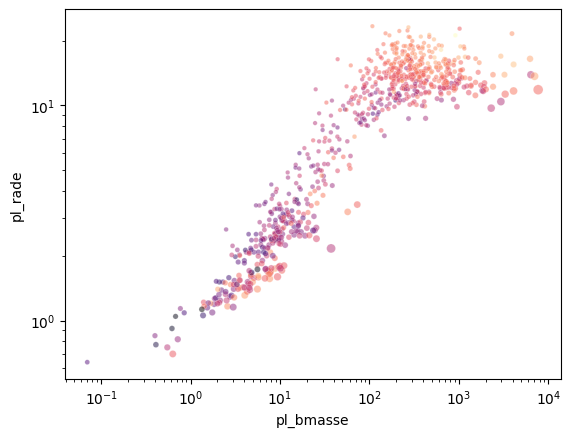

In [20]:
axes = plot.gca()

axes.set_xscale('log')
axes.set_yscale('log')

seaborn.scatterplot(data, x = 'pl_bmasse', y = 'pl_rade', hue = numpy.log10(data['pl_eqt']), size = 'pl_dens', sizes = (10, 50), legend = False, ax = axes, palette = 'magma', alpha = 0.5)

<Axes: xlabel='pl_rade', ylabel='pl_eqt'>

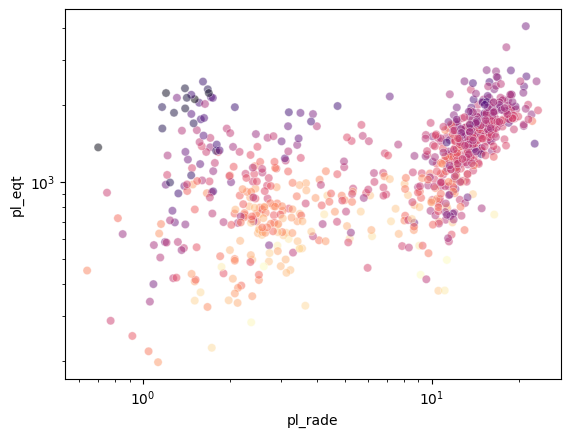

In [8]:
axes = plot.gca()

axes.set_xscale('log')
axes.set_yscale('log')

seaborn.scatterplot(data, x = 'pl_rade', y = 'pl_eqt', hue = numpy.log10(data['pl_orbper']), legend = False, ax = axes, palette = 'magma', alpha = 0.5)

# axes.set_xlim(5)

<Axes: xlabel='pl_rade', ylabel='pl_orbper'>

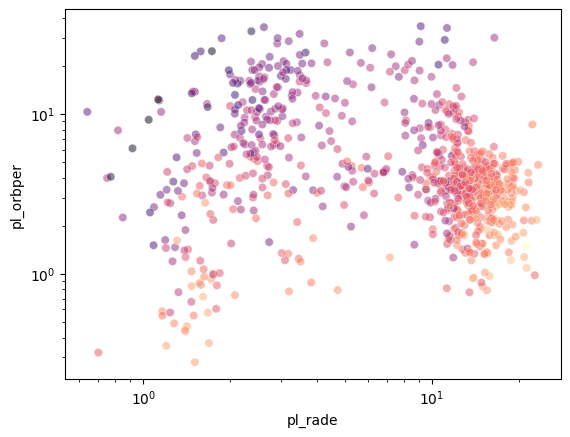

In [9]:
axes = plot.gca()

axes.set_xscale('log')
axes.set_yscale('log')

seaborn.scatterplot(data, x = 'pl_rade', y = 'pl_orbper', hue = numpy.log10(data['pl_eqt']), legend = False, ax = axes, palette = 'magma', alpha = 0.5)

# axes.set_xlim(5)

<Axes: xlabel='pl_bmasse', ylabel='pl_eqt'>

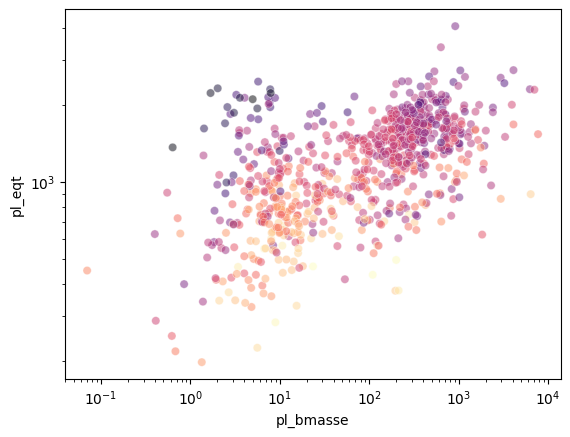

In [ ]:
axes = plot.gca()

axes.set_xscale('log')
axes.set_yscale('log')

seaborn.scatterplot(data, x = 'pl_dens', y = 'pl_eqt', hue = numpy.log10(data['pl_orbper']), legend = False, ax = axes, palette = 'magma', alpha = 0.5)

<Axes: xlabel='pl_bmasse', ylabel='pl_eqt'>

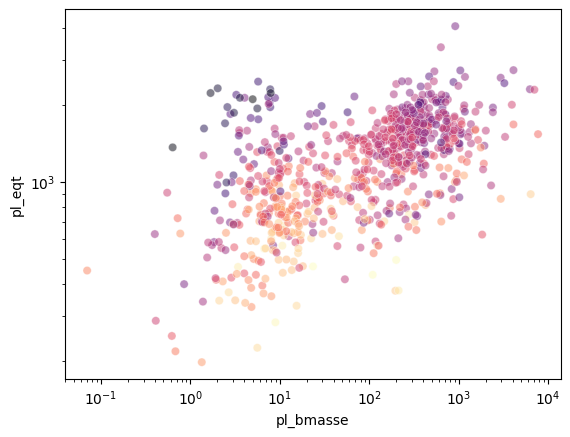

In [11]:
axes = plot.gca()

axes.set_xscale('log')
axes.set_yscale('log')

seaborn.scatterplot(data, x = 'pl_bmasse', y = 'pl_eqt', hue = numpy.log10(data['pl_orbper']), legend = False, ax = axes, palette = 'magma', alpha = 0.5)

# axes.set_xlim(5)

<Axes: xlabel='pl_bmasse', ylabel='pl_dens'>

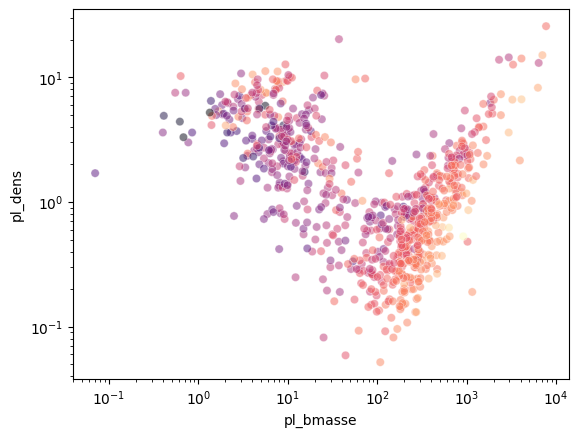

In [18]:
axes = plot.gca()

axes.set_xscale('log')
axes.set_yscale('log')

seaborn.scatterplot(data, x = 'pl_bmasse', y = 'pl_dens', hue = numpy.log10(data['pl_eqt']), legend = False, ax = axes, palette = 'magma', alpha = 0.5)

# axes.set_xlim(5)